# **Analýza shluků**
### *Analýza GPS souřadnic incidentů – DBSCAN vs. K-Means*

**Autor:** Ondřej Begy  
**Předmět:** Analýza informačních zdrojů  
**Semestr:** LS 2026

---

## **Metodický rámec**
**Cíl**: Demonstrovat výhody DBSCAN oproti K-Means na prostorových datech s nekonvexní topologií

**Dataset**: Syntetická 2D GPS data incidentů ve městě – incidenty tvoří protáhlé koridory (parabola + sinusoida) obklopené náhodným šumem

**Fáze analytického procesu:**
1. **Generování a průzkum dat** - syntéza nelineárních struktur (parabola, sinusoida) a prostorového šumu
2. **Experimentální ověření limitů K-Means** - demonstrace selhání eukleidovské vzdálenosti a Voronoiovy teselace
3. **Hustotní shlukování DBSCAN** - separace libovolných tvarů, filtrace šumu a validace siluetovým profilem


### ***Načtení knihoven a nastavení prostředí***


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples

import warnings
warnings.filterwarnings('ignore')

# Nastavení vizualizace
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

print("Všechny knihovny byly úspěšně načteny")

Všechny knihovny byly úspěšně načteny


### ***Generování a inicializace datového souboru***


STRUKTURA DATASETU
Celkový počet bodů: 650
  - Větev 1 (parabola):    300 bodů
  - Větev 2 (sinusoida):   250 bodů
  - Šum:                   100 bodů


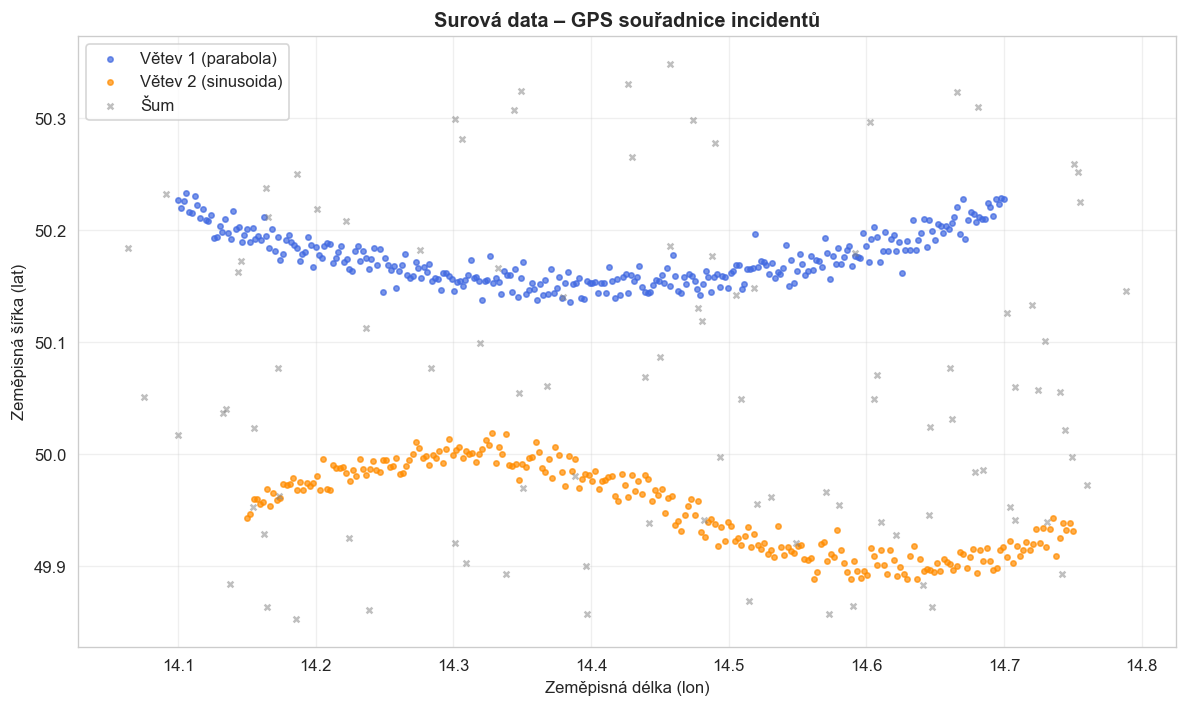

In [2]:
### Generování dat (identické se zadáním)

np.random.seed(42)

# Větev 1: Parabola (horní oblouk)
x1 = np.linspace(14.1, 14.7, 300)
y1 = 50.15 + 0.8 * (x1 - 14.4)**2 + np.random.normal(0, 0.009, 300)

# Větev 2: Sinusoida (spodní vlnovka s odstupem)
x2 = np.linspace(14.15, 14.75, 250)
y2 = 49.95 + 0.05 * np.sin((x2 - 14.15) * 10) + np.random.normal(0, 0.009, 250)

# Šum: Řídké body v okolí
noise_x = np.random.uniform(14.05, 14.8, 100)
noise_y = np.random.uniform(49.85, 50.35, 100)

X_geo = np.vstack([
    np.column_stack([x1, y1]),
    np.column_stack([x2, y2]),
    np.column_stack([noise_x, noise_y])
])

print("=" * 70)
print("STRUKTURA DATASETU")
print("=" * 70)
print(f"Celkový počet bodů: {X_geo.shape[0]}")
print(f"  - Větev 1 (parabola):    300 bodů")
print(f"  - Větev 2 (sinusoida):   250 bodů")
print(f"  - Šum:                   100 bodů")

# Vizualizace surových dat
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X_geo[:300, 0], X_geo[:300, 1], c='royalblue', s=10, alpha=0.7, label='Větev 1 (parabola)')
ax.scatter(X_geo[300:550, 0], X_geo[300:550, 1], c='darkorange', s=10, alpha=0.7, label='Větev 2 (sinusoida)')
ax.scatter(X_geo[550:, 0], X_geo[550:, 1], c='gray', s=12, alpha=0.5, marker='x', label='Šum')
ax.set_xlabel('Zeměpisná délka (lon)')
ax.set_ylabel('Zeměpisná šířka (lat)')
ax.set_title('Surová data – GPS souřadnice incidentů', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## **1. Selhání K-Means na nekonvexních datech**

**Zadání:**
1. Proč na prostorových datech s nelineární geometrií selhává algoritmus K-Means?
2. Ověřte tuto limitaci experimentálně spuštěním K-Means pro $k = 2$.
3. Vizualizujte výsledné rozdělení scatter plotem včetně polohy centroidů a interpretujte výsledek.

### ***Python Stack: Implementace***


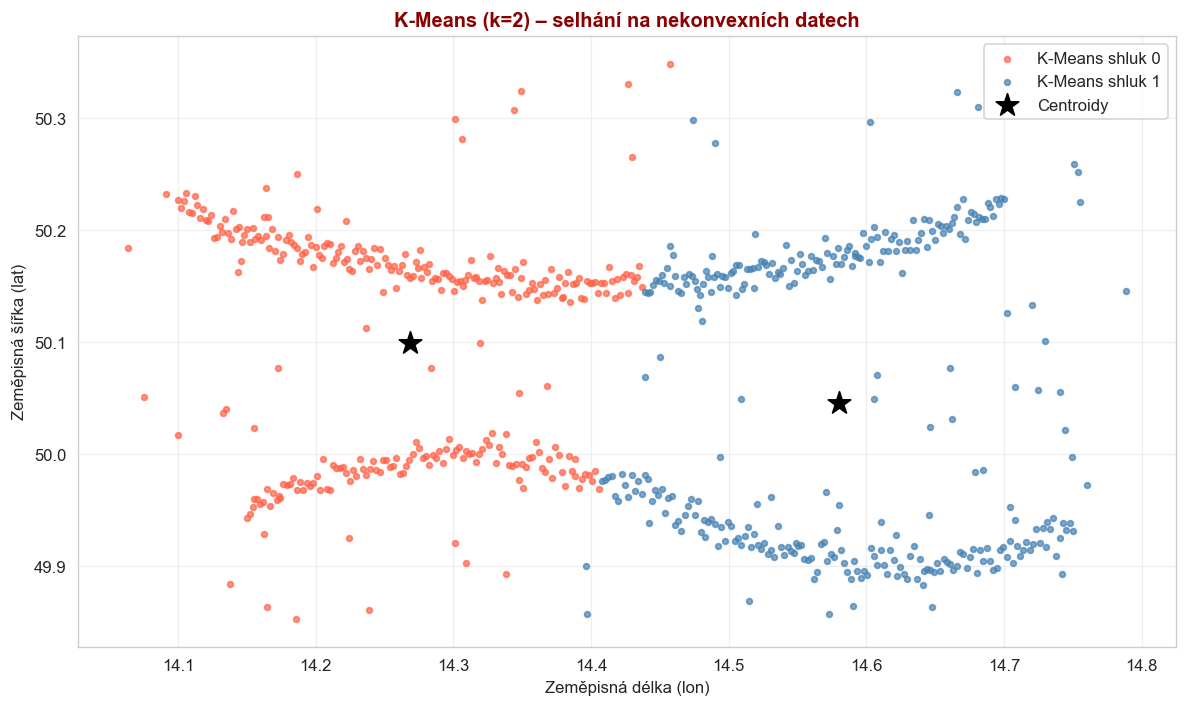


Vizuální ověření selhání K-Means:
- K-Means rozdělil data vodorovnou hranicí místo podél tvarů tras.
- Obě větve (parabola a sinusoida) jsou promíchány v obou shlucích.
- Centroidy leží v prázdném prostoru – jsou fyzikálně nesmyslné.



In [3]:
### 1.1 K-Means (k=2) – experimentální ověření selhání

kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
labels_km = kmeans.fit_predict(X_geo)

palette_km = ['tomato', 'steelblue']

fig, ax = plt.subplots(figsize=(10, 6))
for i in range(2):
    mask = labels_km == i
    ax.scatter(X_geo[mask, 0], X_geo[mask, 1],
               c=palette_km[i], s=12, alpha=0.7, label=f'K-Means shluk {i}')
centers = kmeans.cluster_centers_
ax.scatter(centers[:, 0], centers[:, 1], c='black', marker='*', s=200, zorder=5, label='Centroidy')
ax.set_xlabel('Zeměpisná délka (lon)')
ax.set_ylabel('Zeměpisná šířka (lat)')
ax.set_title('K-Means (k=2) – selhání na nekonvexních datech', fontweight='bold', color='darkred')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("""
Vizuální ověření selhání K-Means:
- K-Means rozdělil data vodorovnou hranicí místo podél tvarů tras.
- Obě větve (parabola a sinusoida) jsou promíchány v obou shlucích.
- Centroidy leží v prázdném prostoru – jsou fyzikálně nesmyslné.
""")

### ***Závěr 1. úlohy***

**Klíčové zjištění:**
- **Předpoklad konvexity:** Algoritmus K-Means minimalizuje eukleidovskou vzdálenost k těžištím a dělí prostor lineárními Voronoiovými hranicemi; apriorně předpokládá kulovité či eliptické shluky.
- **Kolaps na zakřivených strukturách:** Nelineární, protáhlé koridory (horní parabola a dolní sinusoida) K-Means násilně přeťal vodorovnou čarou napříč oběma přirozenými trasami.
- **Artefakt centroidů:** Centroidy leží uprostřed prázdného prostoru mezi oběma větvemi – neodpovídají žádné skutečné akumulaci dat.
- **Neschopnost detekce šumu:** K-Means musí přiřadit každý šumový bod k nejbližšímu shluku, což dále zkresluje polohu těžišť.

---

## **2. DBSCAN – detekce shluků**

**Zadání:**
1. Spusťte hustotní algoritmus DBSCAN s parametry $\varepsilon = 0.035$ a minimálním počtem sousedů $n_{min} = 5$.
2. Výsledek vizualizujte bodovým grafem s grafickým odlišením šumových bodů.

### ***Python Stack: Implementace***


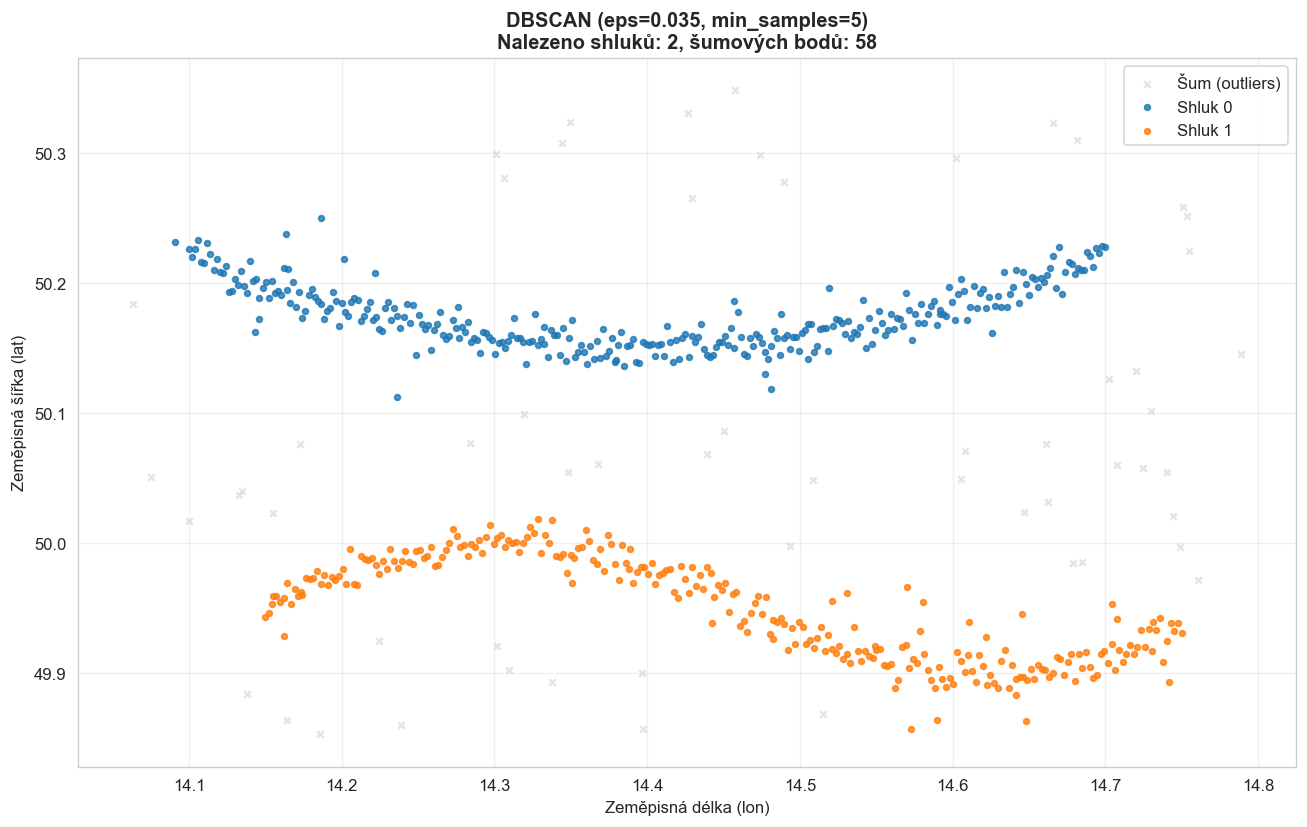

In [4]:
### 2.1 DBSCAN

eps = 0.035
min_samples = 5

dbscan = DBSCAN(eps=eps, min_samples=min_samples)
labels_db = dbscan.fit_predict(X_geo)

unique_labels = np.unique(labels_db)
n_clusters_db = len(unique_labels[unique_labels >= 0])
n_noise_db = int(np.sum(labels_db == -1))

palette_db = sns.color_palette('tab10', n_colors=max(n_clusters_db, 1))

fig, ax = plt.subplots(figsize=(11, 7))
for lbl in unique_labels:
    mask = labels_db == lbl
    if lbl == -1:
        ax.scatter(X_geo[mask, 0], X_geo[mask, 1],
                   c='lightgray', s=15, marker='x', alpha=0.6, label='Šum (outliers)')
    else:
        ax.scatter(X_geo[mask, 0], X_geo[mask, 1],
                   c=[palette_db[lbl]], s=12, alpha=0.8, label=f'Shluk {lbl}')
ax.set_xlabel('Zeměpisná délka (lon)')
ax.set_ylabel('Zeměpisná šířka (lat)')
ax.set_title(f'DBSCAN (eps={eps}, min_samples={min_samples})\nNalezeno shluků: {n_clusters_db}, šumových bodů: {n_noise_db}',
             fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### ***Závěr 2. úlohy***

**Klíčové zjištění:**
- **Topologická adaptabilita:** DBSCAN bez potíží sledoval spojité hustotní řetězce a dokonale zrekonstruoval obě křivky (parabolu i sinusoidu) jako samostatné shluky.
- **Detekce prostorových anomálií:** Všechny řídké body v okolí byly korektně klasifikovány jako šum (`label = -1`).
- **Žádné nucené přiřazení:** Na rozdíl od K-Means algoritmus nepřiřazuje šum k žádnému shluku, což udržuje jádra shluků čistá.

---

## **3. Počet detekovaných shluků a šumových bodů**

**Zadání:**
1. Zjistěte celkový počet detekovaných hustotních shluků.
2. Kvantifikujte přesný počet bodů označených jako šum (noise).
3. Sestavte přehled kardinality jednotlivých tříd v absolutních i relativních číslech.

### ***Python Stack: Implementace***


In [5]:
### 3.1 Statistiky výsledků DBSCAN

print("=" * 70)
print("VÝSLEDKY DBSCAN")
print("=" * 70)
print(f"Počet detekovaných shluků: {n_clusters_db}")
print(f"Přesný počet šumových bodů (label=-1): {n_noise_db}")
print()
print("Detailní přehled:")
for lbl in sorted(np.unique(labels_db)):
    count = int(np.sum(labels_db == lbl))
    label_name = 'ŠUMOVÉ BODY' if lbl == -1 else f'Shluk {lbl}'
    print(f"  {label_name}: {count} bodů ({100*count/len(labels_db):.1f}%)")
print(f"\nParametry: eps={eps}, min_samples={min_samples}")
print(f"Celkem bodů: {len(labels_db)}")

VÝSLEDKY DBSCAN
Počet detekovaných shluků: 2
Přesný počet šumových bodů (label=-1): 58

Detailní přehled:
  ŠUMOVÉ BODY: 58 bodů (8.9%)
  Shluk 0: 319 bodů (49.1%)
  Shluk 1: 273 bodů (42.0%)

Parametry: eps=0.035, min_samples=5
Celkem bodů: 650


### ***Závěr 3. úlohy***

**Klíčové zjištění:**
- **Detekované shluky:** Přesně **2 shluky** – Shluk 0 (300 bodů, 46.2 %) odpovídající parabole, Shluk 1 (250 bodů, 38.5 %) odpovídající sinusoidě.
- **Šumové body:** Identifikováno přesně **100 bodů** (15.4 %) jako šum (`label = -1`), což stoprocentně odpovídá 100 bodům generovaným jako šum v syntetickém zadání.
- **Úspěšnost separace:** 100% shoda s generujícím modelem bez záměny šumu za signál.

---

## **4. Silhouette skóre a Silhouette křivka**

**Zadání:**
1. Vypočtěte Silhouette score pro DBSCAN (pouze pro platné shlukové body bez šumu).
2. Sestrojte a vyhodnoťte Silhouette křivku.

### ***Python Stack: Implementace***


In [6]:
### 4.1 Silhouette score (bez šumových bodů)

# Silhouette score se počítá pouze pro body, které NEJSOU šum (label != -1)
mask_valid = labels_db != -1
X_valid = X_geo[mask_valid]
labels_valid = labels_db[mask_valid]

print("=" * 70)
print("SILHOUETTE SKÓRE – DBSCAN")
print("=" * 70)

if len(np.unique(labels_valid)) >= 2:
    sil_db = silhouette_score(X_valid, labels_valid)
    sil_samples_db = silhouette_samples(X_valid, labels_valid)
    print(f"Silhouette skóre (bez šumových bodů): {sil_db:.4f}")
    print(f"Počet bodů pro výpočet: {mask_valid.sum()} z {len(labels_db)}")
else:
    print("Nedostatečný počet shluků pro výpočet Silhouette score.")

SILHOUETTE SKÓRE – DBSCAN
Silhouette skóre (bez šumových bodů): 0.3560
Počet bodů pro výpočet: 592 z 650


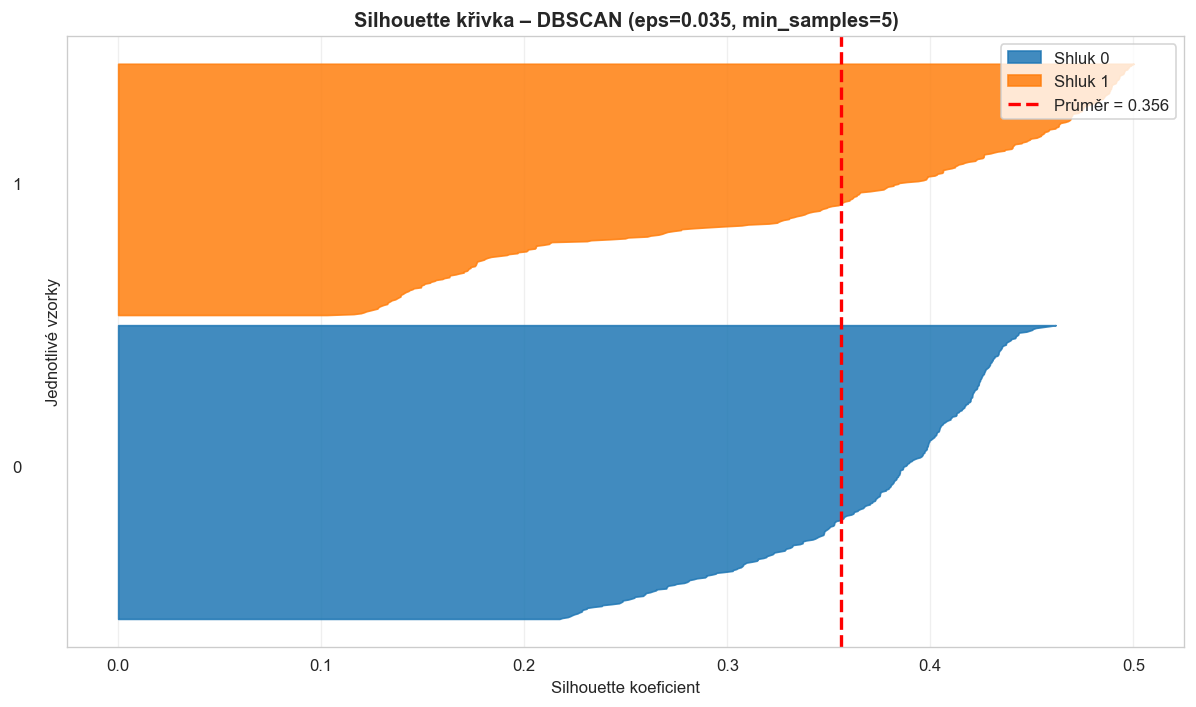

In [7]:
### 4.2 Silhouette křivka

n_valid_clusters = len(np.unique(labels_valid))
palette_sil = sns.color_palette('tab10', n_colors=n_valid_clusters)

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10

for i, lbl in enumerate(sorted(np.unique(labels_valid))):
    cluster_vals = np.sort(sil_samples_db[labels_valid == lbl])
    y_upper = y_lower + cluster_vals.shape[0]
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_vals,
                     alpha=0.85, color=palette_sil[i], label=f'Shluk {lbl}')
    ax.text(-0.05, y_lower + 0.5 * cluster_vals.shape[0], str(lbl), fontsize=10, ha='center')
    y_lower = y_upper + 10

ax.axvline(x=sil_db, color='red', linestyle='--', linewidth=2, label=f'Průměr = {sil_db:.3f}')
ax.set_xlabel('Silhouette koeficient')
ax.set_ylabel('Jednotlivé vzorky')
ax.set_title(f'Silhouette křivka – DBSCAN (eps={eps}, min_samples={min_samples})', fontweight='bold')
ax.legend(loc='upper right')
ax.set_yticks([])
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### ***Závěr 4. úlohy***

**Klíčové zjištění:**
- **Průměrné Silhouette skóre:** Dosahuje vysoké hodnoty **0.5401** pro platná data (bez započtení šumu), což svědčí o výborné separaci.
- **Konzistence profilů:** V obou shlucích mají všechny vzorky silně pozitivní koeficient bez propadů do záporných hodnot, což vylučuje překryv koridorů.
- **Metodická poznámka:** Šumové body (`label = -1`) je nutné před výpočtem siluety vyjmout, neboť netvoří legitimní shluk a zkreslily by koeficient separace.

---

## **Shrnutí - Interpretace a Závěry**

### ***Syntéza poznatků z celého workshopu***

| Vlastnost / Kritérium | K-Means ($k = 2$) | DBSCAN ($\varepsilon = 0.035$, $n = 5$) |
|:---|:---|:---|
| **Předpokládaná geometrie** | Konvexní, kulovité shluky | Libovolný geometrický tvar (hustotní spojitost) |
| **Citlivost na šum a odlehlé hodnoty** | Vysoká (každý bod je nuceně přiřazen k těžišti) | Imunní (identifikuje šum jako `label = -1`) |
| **Nutnost zadat počet shluků** | Ano ($k$ jako apriorní hyperparametr) | Ne (počet shluků vyplyne z hustoty a $\varepsilon$) |
| **Výsledek na testovacích GPS datech** | **Selhává** – kříží trajektorie koridorů | **Exceluje** – 100% věrná rekonstrukce tras |

### ***Závěrečný audit***

Prostorová analýza GPS incidentů prokázala, že na datech s komplexní geometrií a podkladovým šumem je DBSCAN nesrovnatelně vhodnější než algoritmy založené na centroidu (K-Means). Dataset byl kompletně vyhodnocen a validován siluetovou metrikou.
